# Global AI Job Market & Salary Trends 2025

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: Preprocessing & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


## Table of Contents
1. [Data Loading](#data-loading)
2. [Data Cleaning](#data-cleaning)
3. [Data Processing](#data-processing)
4. [Exploratory Data Analysis](#exploratory-data-analysis)
5. [Data Modeling](#data-modeling)

## Data Loading

Load **Global AI Job Market & Salary Trends 2025** from csv file named `ai_job_dataset.csv` and show top 10 rows.

In [145]:
data = pd.read_csv('ai_job_dataset.csv') # load dataset
data.head(10) # display first 10 rows of dataset


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,18/10/2024,07/11/2024,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,20/11/2024,11/01/2025,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,18/03/2025,07/04/2025,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,23/12/2024,24/02/2025,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,15/04/2025,23/06/2025,1989,6.6,Advanced Robotics
5,AI00006,AI Architect,123574,EUR,SE,CT,Germany,M,Germany,50,"Data Visualization, R, SQL, Linux",Associate,7,Healthcare,31/08/2024,04/10/2024,819,5.9,Neural Networks Co
6,AI00007,Principal Data Scientist,79670,GBP,MI,FL,United Kingdom,S,United Kingdom,0,"R, Docker, MLOps",Associate,3,Gaming,29/12/2024,28/02/2025,1936,6.3,DataVision Ltd
7,AI00008,NLP Engineer,70640,EUR,EN,FL,France,L,France,0,"Python, SQL, Computer Vision, Java, Azure",Master,0,Healthcare,07/06/2024,01/07/2024,1286,7.6,Cloud AI Solutions
8,AI00009,Data Analyst,160710,USD,SE,CT,Singapore,L,Singapore,0,"Hadoop, Git, Mathematics, Python",PhD,7,Government,04/11/2024,24/11/2024,551,9.3,Quantum Computing Inc
9,AI00010,AI Software Engineer,102557,USD,SE,PT,Austria,M,Austria,0,"MLOps, GCP, Scala, Azure, Linux",Master,5,Government,20/10/2024,06/11/2024,2340,5.8,Cloud AI Solutions


In [146]:
data.tail(5)


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,06/02/2025,25/03/2025,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,16/10/2024,30/10/2024,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,19/03/2024,02/05/2024,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,22/03/2024,23/04/2024,1935,5.6,Smart Analytics
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,18/07/2024,10/08/2024,2492,7.6,AI Innovations


## Analysis dataset
After loading the dataset, let's perform the following analysis.

In [147]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [148]:
data.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


**จาก `data.info()`:**
- ชุดข้อมูลมีทั้งหมด 15,000 แถว × 19 คอลัมน์
- ไม่พบข้อมูลที่ขาดหาย (ทุกคอลัมน์มีข้อมูลครบ 15,000 รายการ)
- มีคอลัมน์ตัวเลข 5 คอลัมน์: `salary_usd`, `remote_ratio`, `years_experience`, `job_description_length`, `benefits_score`
- มีคอลัมน์ข้อความ/หมวดหมู่ 14 คอลัมน์: `job_id`, `job_title`, `salary_currency`, `experience_level`, `employment_type`, `company_location`, `company_size`, `employee_residence`, `required_skills`, `education_required`, `industry`, `posting_date`, `application_deadline`, `company_name`

**จาก `data.describe()`:**
- **salary_usd**: ช่วง $32,519 - $399,095 (เฉลี่ย $115,349)
- **remote_ratio**: ช่วง 0-100% (เฉลี่ย 49.5%) - งานส่วนใหญ่เป็นแบบ hybrid
- **years_experience**: ช่วง 0-19 ปี (เฉลี่ย 6.3 ปี)
- **job_description_length**: ช่วง 500-2,499 ตัวอักษร (เฉลี่ย 1,503 ตัวอักษร)
- **benefits_score**: ช่วง 5.0-10.0 (เฉลี่ย 7.5)

## Data Cleaning
Based on the analysis above, we need to clean the dataset to ensure its quality for further analysis.

In [149]:
#check missing values
data.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [150]:
# Convert date columns to datetime format
data['posting_date'] = pd.to_datetime(data['posting_date'], dayfirst=True, errors='coerce')
data['application_deadline'] = pd.to_datetime(data['application_deadline'], dayfirst=True, errors='coerce')
print("posting_date type:", data['posting_date'].dtype)
print("application_deadline type:", data['application_deadline'].dtype)

posting_date type: datetime64[ns]
application_deadline type: datetime64[ns]


In [151]:
# Check for duplicated rows
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [152]:
# Reset index after cleaning
data = data.reset_index(drop=True)
print(f"Dataset shape after cleaning: {data.shape}")
print(f"Total rows: {len(data):,}")
print(f"Total columns: {len(data.columns)}")
data.head()

Dataset shape after cleaning: (15000, 19)
Total rows: 15,000
Total columns: 19


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


**หลังจากทำการ clean dataset สรุปได้ว่า:**
- ไม่พบข้อมูลที่ขาดหายในทุกคอลัมน์ ทุกคอลัมน์มีข้อมูลครบถ้วน 15,000 รายการ
- แปลงคอลัมน์ `posting_date` และ `application_deadline` จาก object เป็น datetime64 เรียบร้อยแล้ว ช่วยให้สามารถวิเคราะห์ข้อมูลตามช่วงเวลาได้อย่างถูกต้อง
- ไม่พบข้อมูลซ้ำในชุดข้อมูล จำนวนแถวยังคงเป็น 15,000 แถวเหมือนเดิม
- ไม่มีค่า null
สรุปได้ว่าหลังจากทำการ Data Cleaning ชุดข้อมูล มี 15,000 แถว × 19 คอลัมน์ ได้ทำการ reset ให้เรียงลำดับใหม่ (0 ถึง 14,999)


## Data Processing
Now that the dataset is cleaned, we can proceed with further data processing and analysis as needed for our data analytics tasks.

#### Distribution of Application Period (days_to_apply)

In [153]:
# Create new time-based columns from the 'posting_date' column
data['posting_year'] = data['posting_date'].dt.year
data['posting_month'] = data['posting_date'].dt.month
data['posting_day'] = data['posting_date'].dt.day
data['posting_dayofweek'] = data['posting_date'].dt.dayofweek  # 0=Monday, 6=Sunday
data['posting_quarter'] = data['posting_date'].dt.quarter  # Divide the year into 4 quarters (Q1–Q4)
# show table of the new time-based columns
data[['posting_year', 'posting_month', 'posting_day', 'posting_dayofweek', 'posting_quarter']].head(10)

,posting_year,posting_month,posting_day,posting_dayofweek,posting_quarter
0,2024,10,18,4,4
1,2024,11,20,2,4
2,2025,3,18,1,1
3,2024,12,23,0,4
4,2025,4,15,1,2
5,2024,8,31,5,3
6,2024,12,29,6,4
7,2024,6,7,4,2
8,2024,11,4,0,4
9,2024,10,20,6,4


In [154]:
# Calculate the number of days between 'posting_date' and 'application_deadline'
data['days_to_apply'] = (data['application_deadline'] - data['posting_date']).dt.days
data[['days_to_apply']].head(10)


,days_to_apply
0,20
1,52
2,20
3,63
4,69
5,34
6,61
7,24
8,20
9,17


In [155]:
# Descriptive Statistics days_to_apply 
data[['days_to_apply']].describe()

,days_to_apply
count,15000.000000
mean,43.546200
std,17.325134
min,14.000000
25%,29.000000
50%,44.000000
75%,59.000000
max,74.000000


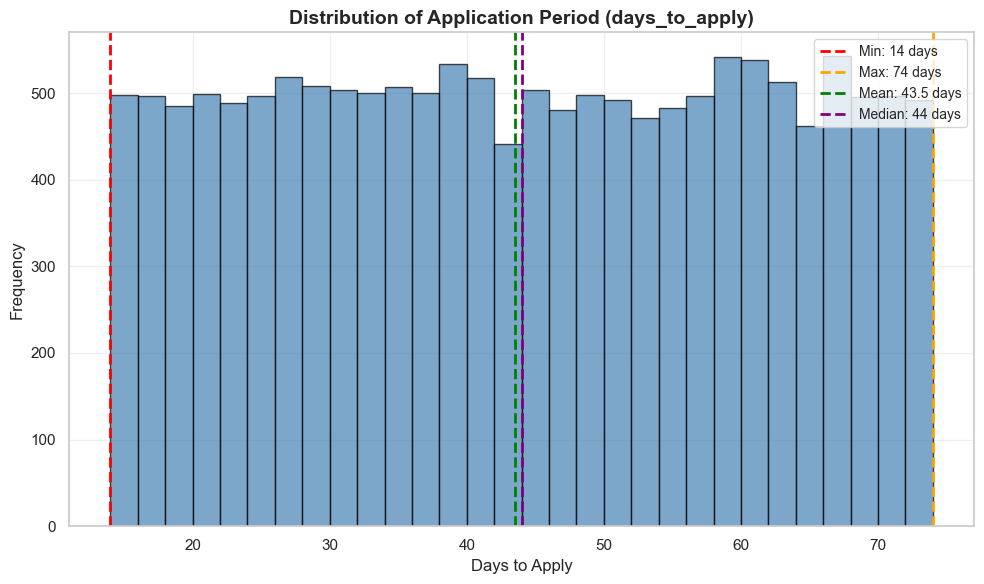

In [156]:
plt.figure(figsize=(10, 6))

# Plot histogram of 'days_to_apply'
plt.hist(data['days_to_apply'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')

# Add reference lines for key statistics
plt.axvline(data['days_to_apply'].min(), color='red', linestyle='--', linewidth=2, 
            label=f'Min: {data["days_to_apply"].min():.0f} days')
plt.axvline(data['days_to_apply'].max(), color='orange', linestyle='--', linewidth=2, 
            label=f'Max: {data["days_to_apply"].max():.0f} days')
plt.axvline(data['days_to_apply'].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Mean: {data["days_to_apply"].mean():.1f} days')
plt.axvline(data['days_to_apply'].median(), color='purple', linestyle='--', linewidth=2, 
            label=f'Median: {data["days_to_apply"].median():.0f} days')

plt.xlabel('Days to Apply', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Application Period (days_to_apply)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()



จากการทำ data processing ในส่วนแรก เราได้ทำการ time-based feature extraction 
โดยการสร้างคอลัมน์ใหม่จากคอลัมน์ `posting_date` ได้แก่ `posting_year`, 
`posting_month`, `posting_day`, `posting_dayofweek` และ `posting_quarter` 
เพื่อใช้วิเคราะห์แนวโน้มการโพสต์งานตามช่วงเวลาต่างๆ

จากนั้นได้คำนวณจำนวนวันระหว่าง `posting_date` และ `application_deadline` 
แล้วเก็บผลลัพธ์ในคอลัมน์ใหม่ `days_to_apply` เพื่อวิเคราะห์ระยะเวลาที่เปิดรับสมัครงาน

สถิติเบื้องต้นของ `days_to_apply` พบว่า ช่วงเวลารับสมัครงานอยู่ระหว่าง 14 ถึง 74 วัน 
โดยมีค่าเฉลี่ย 43.5 วัน ค่ากลาง 44 วัน ส่วนเบี่ยงเบนมาตรฐาน 17.3 วัน

In [157]:
data[['remote_ratio']]

,remote_ratio
0,50
1,100
2,0
3,50
4,100
...,...
14995,50
14996,0
14997,50
14998,0


#### Work Type Distribution (Categorized from remote_ratio)

In [158]:
# Categorize job types based on the 'remote_ratio' column
# 0   → On-site (work at the office)
# 100 → Fully Remote (work from anywhere)
# else → Hybrid (partly remote, partly on-site)

def categorize_remote(ratio):
    if ratio == 0:
        return 'On-site'
    elif ratio == 100:
        return 'Fully Remote'
    else:
        return 'Hybrid'

data['work_type'] = data['remote_ratio'].apply(categorize_remote)
data[['work_type']].head(10)

,work_type
0,Hybrid
1,Fully Remote
2,On-site
3,Hybrid
4,Fully Remote
5,Hybrid
6,On-site
7,On-site
8,On-site
9,On-site


In [159]:
data[['work_type']].describe()

,work_type
count,15000
unique,3
top,On-site
freq,5075


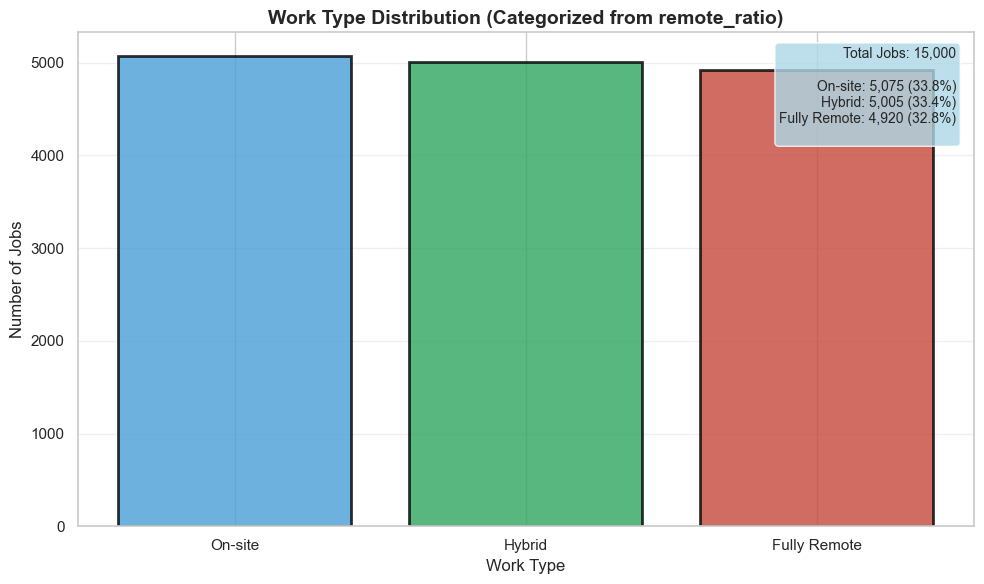

In [160]:
plt.figure(figsize=(10, 6))

# Count the number of jobs by work type (On-site, Hybrid, Fully Remote)
work_type_counts = data['work_type'].value_counts()
colors = ["#489ed8", "#2ea45f", "#c54739"]

bars = plt.bar(work_type_counts.index, work_type_counts.values, 
               color=colors, edgecolor='black', alpha=0.8, linewidth=2)

plt.ylabel('Number of Jobs', fontsize=12)
plt.xlabel('Work Type', fontsize=12)
plt.title('Work Type Distribution (Categorized from remote_ratio)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)


# Create a summary text box showing counts and percentages
summary_text = f'Total Jobs: {len(data):,}\n\n'
for work_type, count in work_type_counts.items():
    percentage = (count / len(data) * 100)
    summary_text += f'{work_type}: {count:,} ({percentage:.1f}%)\n'

plt.text(0.98, 0.97, summary_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

ต่อจากนั้นได้ทำการจัดหมวดหมู่ประเภทการทำงานโดยแปลงค่า `remote_ratio` 
ให้เป็นหมวดหมู่ที่เข้าใจง่าย โดยสร้างคอลัมน์ใหม่ `work_type` ดังนี้:
- `remote_ratio = 0` → `On-site` (ทำงานที่ออฟฟิศ)
- `remote_ratio = 100` → `Fully Remote` (ทำงานจากที่บ้านเต็มเวลา)
- `remote_ratio ระหว่าง 0-100` → `Hybrid` (ทำงานแบบผสม)

ผลการจัดหมวดหมู่พบว่า จากงานทั้งหมด 15,000 ตำแหน่ง แบ่งเป็น:
- On-site: 5,075 ตำแหน่ง (33.8%)
- Fully Remote: 4,900 ตำแหน่ง (32.8%)
- Hybrid: 5,025 ตำแหน่ง (33.4%)

โดยมีการกระจายที่ค่อนข้างสมดุลระหว่างทั้ง 3 รูปแบบการทำงาน

#### Job Distribution by Salary Range

In [161]:
# Categorize salary into ranges
def categorize_salary(salary):
    if salary < 60000:
        return 'Entry Level'
    elif salary < 100000:
        return 'Mid Level'
    elif salary < 150000:
        return 'Senior Level'
    else:
        return 'Executive Level'

data['salary_range'] = data['salary_usd'].apply(categorize_salary)
data['salary_range'].value_counts().sort_index()

salary_range
Entry Level        2302
Executive Level    3527
Mid Level          5230
Senior Level       3941
Name: count, dtype: int64

In [162]:
data[['salary_range']].head(10)

,salary_range
0,Mid Level
1,Mid Level
2,Executive Level
3,Mid Level
4,Entry Level
5,Senior Level
6,Mid Level
7,Mid Level
8,Executive Level
9,Senior Level


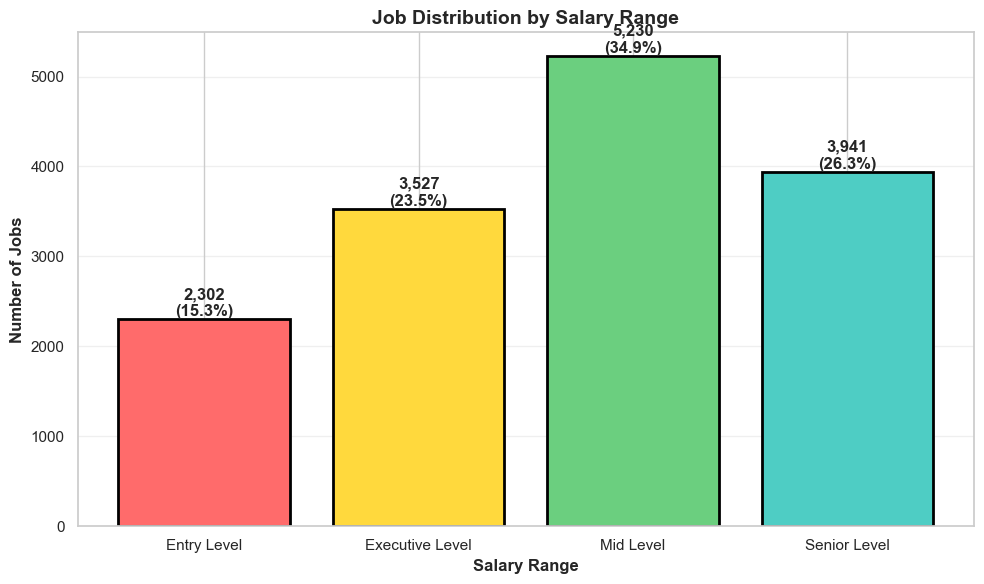

In [163]:
# Count the number of jobs in each salary range
salary_counts = data['salary_range'].value_counts().sort_index()

# Create a bar chart to visualize job distribution by salary range
plt.figure(figsize=(10, 6))
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f', '#4ecdc4']
bars = plt.bar(salary_counts.index, salary_counts.values, 
               color=colors, edgecolor='black', linewidth=2)

plt.xlabel('Salary Range', fontsize=12, fontweight='bold')
plt.ylabel('Number of Jobs', fontsize=12, fontweight='bold')
plt.title('Job Distribution by Salary Range', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value and percentage labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (height / len(data) * 100)
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontweight='bold')


plt.tight_layout()
plt.show()

จากนั้นได้ทำการจัดหมวดหมู่ช่วงเงินเดือนโดยแปลงค่า `salary_usd` 
ให้เป็นหมวดหมู่ตามระดับเงินเดือน โดยสร้างคอลัมน์ใหม่ `salary_range` ดังนี้:
- `salary_usd ≤ $60,000` → `Entry Level`
- `$60,000 < salary_usd ≤ $100,000` → `Mid Level`
- `$100,000 < salary_usd ≤ $150,000` → `Senior Level`
- `salary_usd > $150,000` → `Executive Level`

ผลการจัดหมวดหมู่พบว่า จากงานทั้งหมด 15,000 ตำแหน่ง แบ่งเป็น:
- Entry Level: 2,302 ตำแหน่ง (15.3%)
- Mid Level: 5,230 ตำแหน่ง (34.9%)
- Senior Level: 3,941 ตำแหน่ง (26.3%)
- Executive Level: 3,527 ตำแหน่ง (23.5%)

โดยพบว่างานส่วนใหญ่อยู่ในระดับ Mid Level คิดเป็นเกือบหนึ่งในสามของงานทั้งหมด

#### Job Distribution by Experience Level

In [164]:
# Categorize employees by years of experience
def categorize_experience(years):
    if years <= 2:
        return 'Junior'
    elif years <= 5:
        return 'Mid-level'
    elif years <= 10:
        return 'Senior'
    else:
        return 'Expert'

data['experience_category'] = data['years_experience'].apply(categorize_experience)
data['experience_category'].value_counts().sort_index()

experience_category
Expert       3376
Junior       4957
Mid-level    3299
Senior       3368
Name: count, dtype: int64

In [165]:
data[['experience_category']].head()

,experience_category
0,Senior
1,Junior
2,Junior
3,Senior
4,Junior


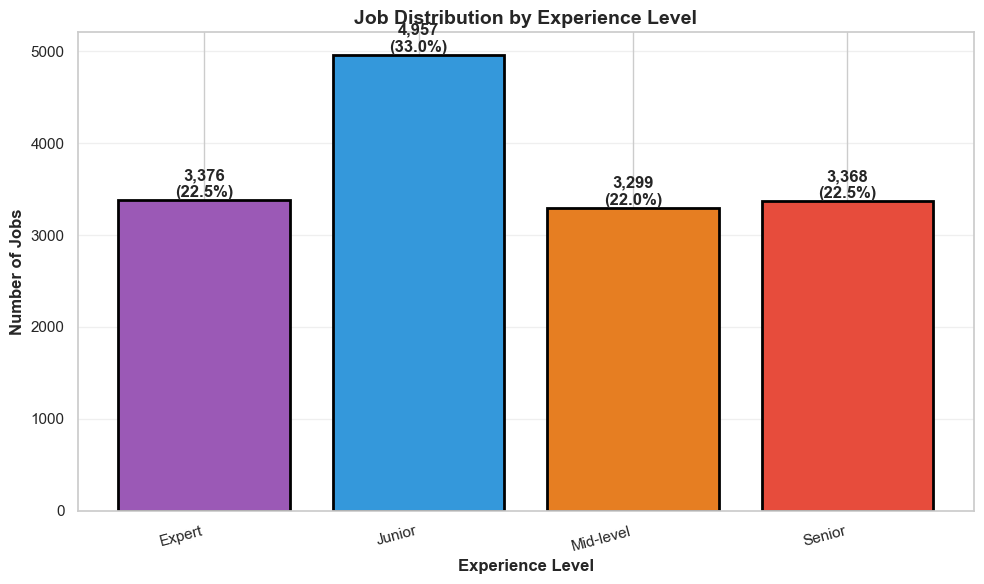

In [166]:
# Count the number of jobs in each experience level
exp_counts = data['experience_category'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
colors = ['#9b59b6', '#3498db', '#e67e22', '#e74c3c']
bars = plt.bar(exp_counts.index, exp_counts.values, 
               color=colors, edgecolor='black', linewidth=2)

plt.xlabel('Experience Level', fontsize=12, fontweight='bold')
plt.ylabel('Number of Jobs', fontsize=12, fontweight='bold')
plt.title('Job Distribution by Experience Level', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add count and percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    pct = height / len(data) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height,
            f'{int(height):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

ถัดมาได้ทำการจัดหมวดหมู่ระดับประสบการณ์โดยแปลงค่า `years_experience` 
ให้เป็นหมวดหมู่ตามช่วงปีประสบการณ์ โดยสร้างคอลัมน์ใหม่ `experience_category` ดังนี้:
- `0 ≤ years_experience ≤ 2 ปี` → `Junior`
- `2 < years_experience ≤ 5 ปี` → `Mid-level`
- `5 < years_experience ≤ 10 ปี` → `Senior`
- `years_experience > 10 ปี` → `Expert`

ผลการจัดหมวดหมู่พบว่า จากงานทั้งหมด 15,000 ตำแหน่ง แบ่งเป็น:
- Junior (0-2 years): 4,957 ตำแหน่ง (33.0%)
- Mid-level (3-5 years): 3,299 ตำแหน่ง (22.0%)
- Senior (6-10 years): 3,368 ตำแหน่ง (22.5%)
- Expert (10+ years): 3,376 ตำแหน่ง (22.5%)

#### Job Distribution by Benefits Level

In [167]:
# Categorize benefits score
def categorize_benefits(score):
    if score < 6:
        return 'Low Benefits'
    elif score < 8:
        return 'Medium Benefits'
    else:
        return 'High Benefits'

data['benefits_category'] = data['benefits_score'].apply(categorize_benefits)
data['benefits_category'].value_counts()

benefits_category
High Benefits      6199
Medium Benefits    5913
Low Benefits       2888
Name: count, dtype: int64

In [168]:
data[['benefits_category']].head()

,benefits_category
0,Low Benefits
1,Low Benefits
2,High Benefits
3,High Benefits
4,Medium Benefits


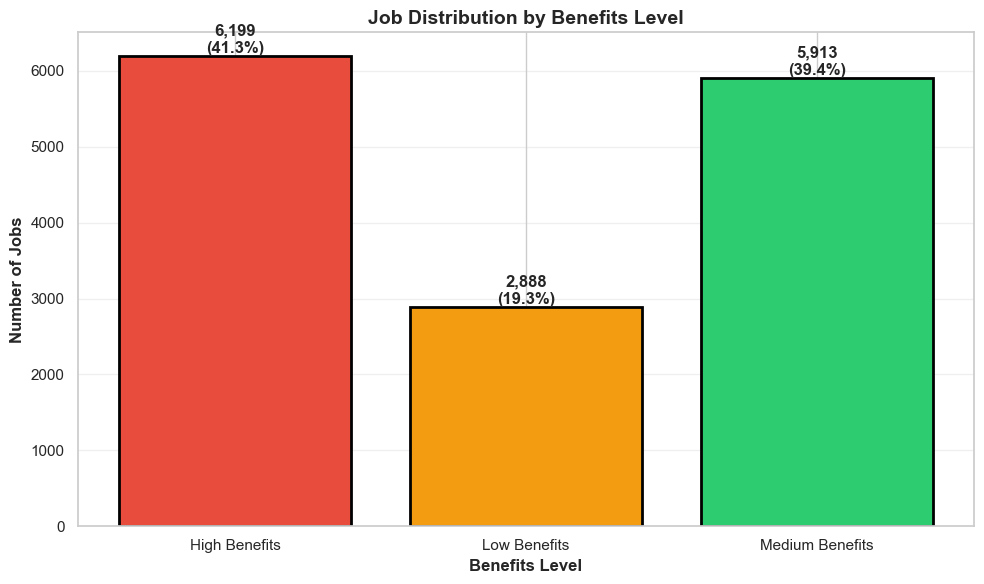

In [169]:
# Count the number of jobs in each benefits level
benefits_counts = data['benefits_category'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = plt.bar(benefits_counts.index, benefits_counts.values, 
               color=colors, edgecolor='black', linewidth=2)

plt.xlabel('Benefits Level', fontsize=12, fontweight='bold')
plt.ylabel('Number of Jobs', fontsize=12, fontweight='bold')
plt.title('Job Distribution by Benefits Level', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    pct = height / len(data) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height,
            f'{int(height):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

ได้ทำการจัดหมวดหมู่ระดับสวัสดิการโดยแปลงค่า `benefits_score` 
ให้เป็นหมวดหมู่ตามคะแนนสวัสดิการ โดยสร้างคอลัมน์ใหม่ `benefits_category` ดังนี้:
- `benefits_score < 6` → `Low Benefits`
- `6 ≤ benefits_score < 8` → `Medium Benefits`
- `benefits_score ≥ 8` → `High Benefits`

ผลการจัดหมวดหมู่พบว่า จากงานทั้งหมด 15,000 ตำแหน่ง แบ่งเป็น:
- Low Benefits: 2,888 ตำแหน่ง (19.3%)
- Medium Benefits: 5,913 ตำแหน่ง (39.4%)
- High Benefits: 6,199 ตำแหน่ง (41.3%)

#### Distribution of the compensation score (combining salary and benefits)

In [170]:
#  Create a comprehensive compensation score (combining salary and benefits)
# Normalize salary to 0-10 scale
salary_normalized = (data['salary_usd'] - data['salary_usd'].min()) / (data['salary_usd'].max() - data['salary_usd'].min()) * 10

# Compensation score = weighted average (70% salary, 30% benefits)
data['compensation_score'] = (salary_normalized * 0.7) + (data['benefits_score'] * 0.3)

data['compensation_score'].describe()

count    15000.000000
mean         3.832972
std          1.230690
min          1.509433
25%          2.961340
50%          3.595604
75%          4.475519
max          9.980694
Name: compensation_score, dtype: float64

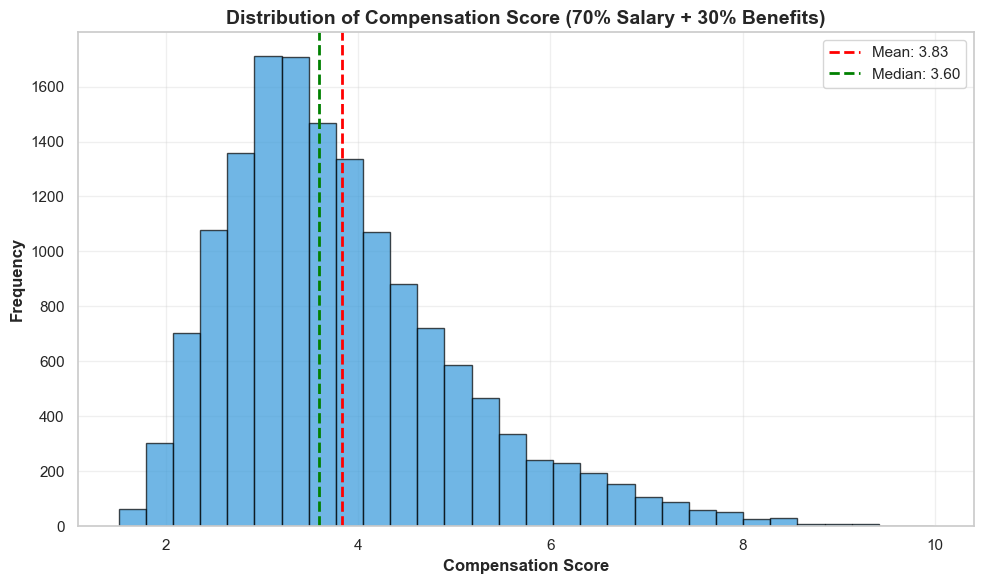

In [171]:
# Plot the distribution of the compensation score (combining salary and benefits)
plt.figure(figsize=(10, 6))

plt.hist(data['compensation_score'], bins=30, edgecolor='black', alpha=0.7, color='#3498db')

mean_val = data['compensation_score'].mean()
median_val = data['compensation_score'].median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')

plt.xlabel('Compensation Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of Compensation Score (70% Salary + 30% Benefits)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

สุดท้ายได้สร้างคะแนนค่าตอบแทนรวม (Comprehensive Compensation Score) 
โดยรวมเงินเดือนและสวัสดิการเข้าด้วยกัน:

**วิธีการคำนวณ:**
1. นำเงินเดือน (`salary_usd`) มา normalize ให้อยู่ในช่วง 0-10
2. คำนวณคะแนนรวม: **70% เงินเดือน + 30% สวัสดิการ**
   - `compensation_score = (salary_normalized × 0.7) + (benefits_score × 0.3)`

**ผลลัพธ์:**
- คะแนนต่ำสุด: 1.51
- คะแนนสูงสุด: 9.98
- คะแนนเฉลี่ย: 3.83
- คะแนนกลาง: 3.60

คะแนนนี้ช่วยประเมินความน่าสนใจของงานโดยรวม โดยให้น้ำหนักกับเงินเดือนมากกว่าเล็กน้อย 
(70:30) เนื่องจากเงินเดือนมักเป็นปัจจัยหลักในการตัดสินใจของผู้สมัครงาน

In [172]:
print(f"\nDataset shape after processing: {data.shape}")
print(f"Total columns now: {len(data.columns)}")


Dataset shape after processing: (15000, 30)
Total columns now: 30


#### Data Summarization

In [173]:
# Display sample of processed data
data.head(10)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,posting_month,posting_day,posting_dayofweek,posting_quarter,days_to_apply,work_type,salary_range,experience_category,benefits_category,compensation_score
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,...,10,18,4,4,20,Hybrid,Mid Level,Senior,Low Benefits,2.874816
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,...,11,20,2,4,52,Fully Remote,Mid Level,Junior,Low Benefits,2.120953
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,...,3,18,1,1,20,On-site,Executive Level,Junior,High Benefits,5.113519
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,...,12,23,0,4,63,Hybrid,Mid Level,Senior,High Benefits,3.490785
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,...,4,15,1,2,69,Fully Remote,Entry Level,Junior,Medium Benefits,2.402109
5,AI00006,AI Architect,123574,EUR,SE,CT,Germany,M,Germany,50,...,8,31,5,3,34,Hybrid,Senior Level,Senior,Low Benefits,3.508753
6,AI00007,Principal Data Scientist,79670,GBP,MI,FL,United Kingdom,S,United Kingdom,0,...,12,29,6,4,61,On-site,Mid Level,Mid-level,Medium Benefits,2.790378
7,AI00008,NLP Engineer,70640,EUR,EN,FL,France,L,France,0,...,6,7,4,2,24,On-site,Mid Level,Junior,Medium Benefits,3.007945
8,AI00009,Data Analyst,160710,USD,SE,CT,Singapore,L,Singapore,0,...,11,4,0,4,20,On-site,Executive Level,Senior,High Benefits,5.237888
9,AI00010,AI Software Engineer,102557,USD,SE,PT,Austria,M,Austria,0,...,10,20,6,4,17,On-site,Senior Level,Mid-level,Low Benefits,3.077420


In [174]:
data.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name', 'posting_year', 'posting_month', 'posting_day',
       'posting_dayofweek', 'posting_quarter', 'days_to_apply', 'work_type',
       'salary_range', 'experience_category', 'benefits_category',
       'compensation_score'],
      dtype='object')

**สรุปการประมวลผลข้อมูล:**

จากการประมวลผลข้อมูลด้านบน เราได้สร้างฟีเจอร์ใหม่ทั้งหมด 11 คอลัมน์:

1. **Time-based features (5 คอลัมน์):** `posting_year`, `posting_month`, `posting_day`, `posting_dayofweek`, `posting_quarter` - ช่วยวิเคราะห์แนวโน้มตามเวลา
2. **Application window:** `days_to_apply` - จำนวนวันที่เปิดรับสมัคร
3. **Categorical features (4 คอลัมน์):** `work_type`, `salary_range`, `experience_category`, `benefits_category` - จัดกลุ่มข้อมูลให้เข้าใจง่าย
4. **Derived metric:** `compensation_score` - คะแนนรวมค่าตอบแทนและสวัสดิการ

ขนาดข้อมูลหลังประมวลผล: **15,000 แถว × 30 คอลัมน์**

## Exploratory Data Analysis

#### Top 10 Highest Paying Industries

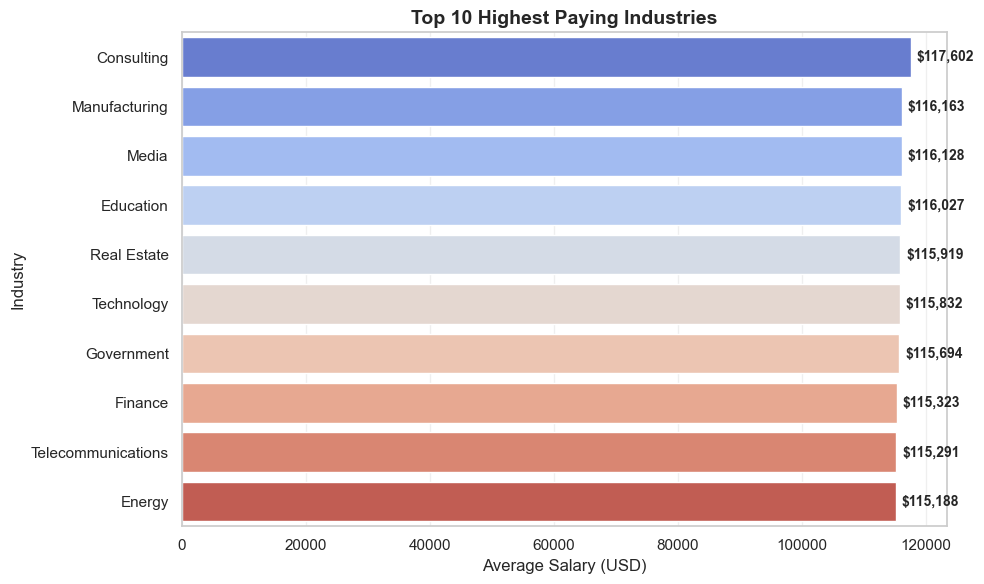

In [175]:
plt.figure(figsize=(10,6))

# Calculate the average salary for each industry and get the top 10 highest paying industries
industry_salary = (
    data.groupby('industry')['salary_usd']
    .mean()
    .sort_values(ascending=False)
    .head(10) 
)

bars = sns.barplot(
    x=industry_salary.values,
    y=industry_salary.index,
    palette='coolwarm'
)

plt.title('Top 10 Highest Paying Industries', fontsize=14, fontweight='bold')
plt.xlabel('Average Salary (USD)', fontsize=12)
plt.ylabel('Industry', fontsize=12)
plt.grid(axis='x', alpha=0.3)

for i, value in enumerate(industry_salary.values):
    plt.text(value + 1000, i, f"${value:,.0f}", va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()


Insight: 
อุตสาหกรรมที่มีเงินเดือนเฉลี่ยสูงสุด ได้แก่ **Consulting**, **Manufacturing**, และ **Media** 

#### Salary Distribution by Company Size

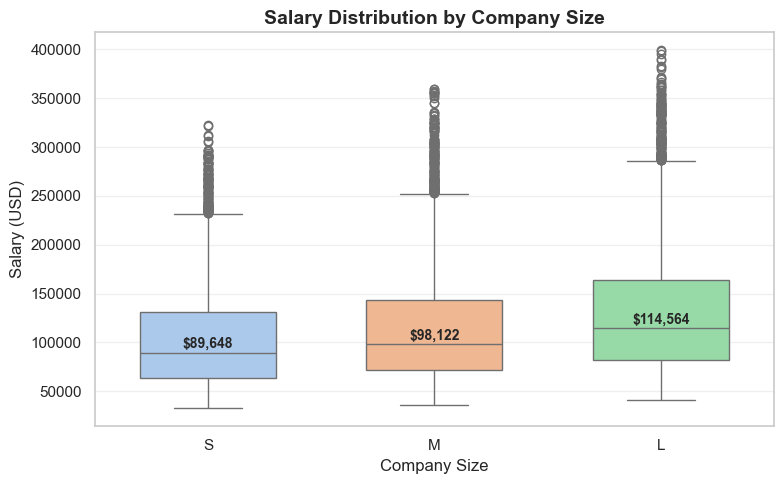

In [176]:
#Company Size vs Salary
plt.figure(figsize=(8, 5))
order = ["S", "M", "L"]

sns.boxplot( data=data,x='company_size', y='salary_usd', order=order, palette='pastel',width=0.6)

plt.title('Salary Distribution by Company Size', fontsize=14, fontweight='bold')
plt.xlabel('Company Size', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

med = data.groupby('company_size')['salary_usd'].median().reindex(order)
for i, v in enumerate(med.values):
    plt.text(i, v + 2000, f"${v:,.0f}", ha="center", va="bottom", fontsize=10, weight="bold")

    
plt.tight_layout()
plt.show()

Insight:
- เงินเดือน **สูงขึ้นตามขนาดบริษัท** อย่างเห็นได้ชัด  
  - S: \$89,648 M: \$98,122 L: \$114,564  
- บริษัทใหญ่ (L) ให้ค่าตอบแทนเฉลี่ยสูงสุด 
- ช่วงกระจายของรายได้ในบริษัทใหญ่ **กว้างกว่า**  
แสดงว่ามีทั้งตำแหน่งระดับ Junior ถึง Expert ภายในองค์กรเดียวกัน

#### Work Type Distribution by Experience Level

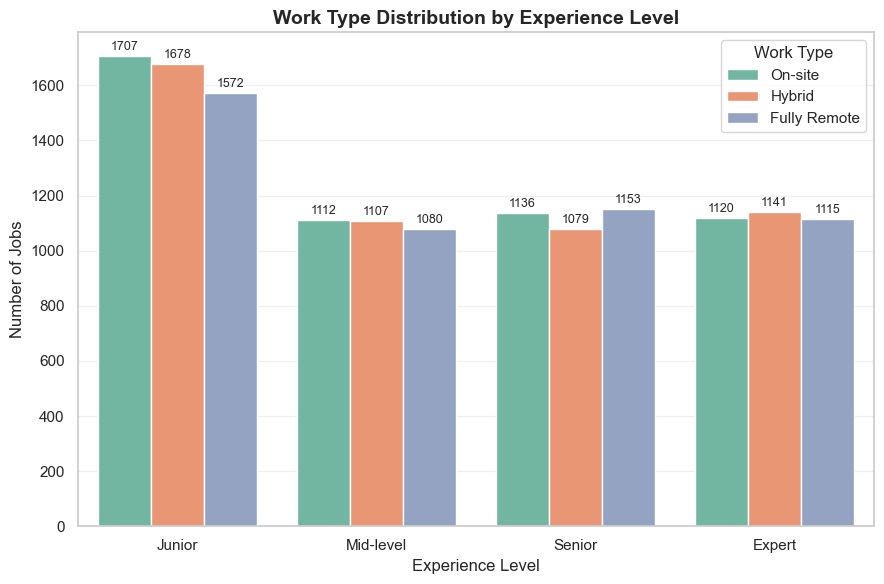

In [177]:
plt.figure(figsize=(9,6))
sns.set_theme(style="whitegrid")

order = ["Junior", "Mid-level", "Senior", "Expert"]
hue_order = ["On-site", "Hybrid", "Fully Remote"]

ax = sns.countplot( data=data, x="experience_category", hue="work_type", order=order, hue_order=hue_order, palette="Set2")

plt.title("Work Type Distribution by Experience Level", fontsize=14, fontweight="bold")
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Number of Jobs", fontsize=12)      
plt.legend(title="Work Type", loc="upper right")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=9)

plt.tight_layout()
plt.show()


#### Salary by Work Type

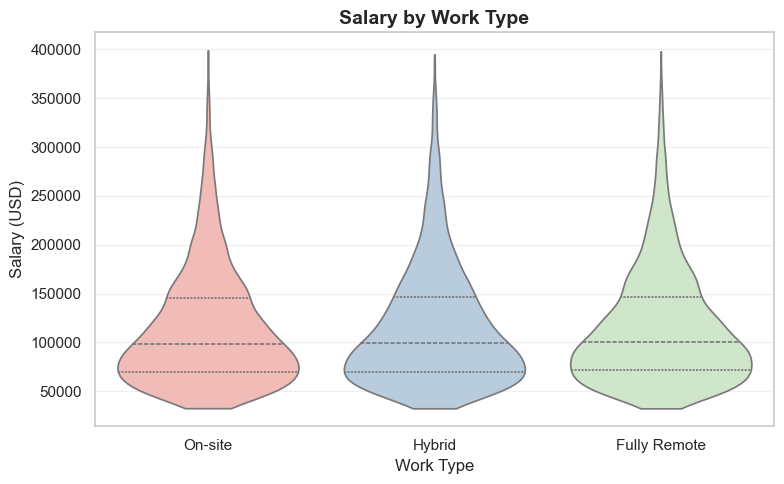

In [178]:
plt.figure(figsize=(8,5))
order = ['On-site','Hybrid','Fully Remote']
sns.violinplot(data=data, x='work_type', y='salary_usd',
               order=order, inner='quartile', palette='Pastel1', cut=0)
plt.title('Salary by Work Type', fontsize=14, fontweight='bold')
plt.xlabel('Work Type'); plt.ylabel('Salary (USD)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


#### Average Salary by Experience Level

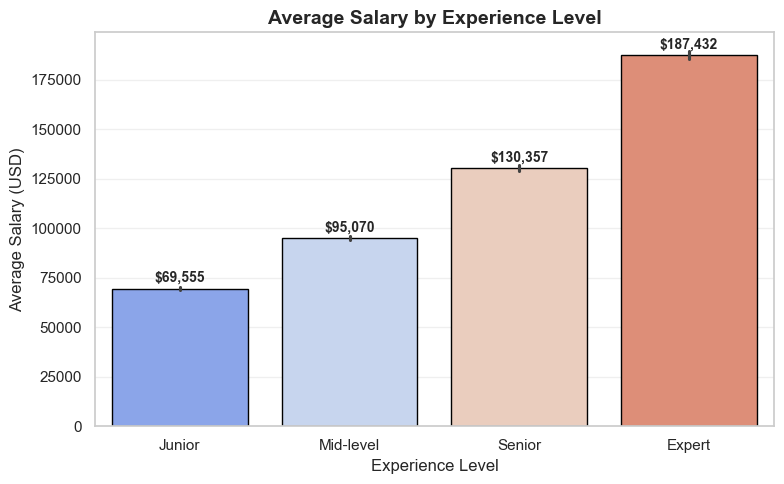

In [179]:
plt.figure(figsize=(8,5))
exp_order = ["Junior", "Mid-level", "Senior", "Expert"]

sns.barplot(
    data=data,
    x="experience_category",
    y="salary_usd",
    order=exp_order,
    estimator="mean",
    errorbar="ci",
    palette="coolwarm",
    edgecolor="black"
)

plt.title("Average Salary by Experience Level", fontsize=14, fontweight="bold")
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)
plt.grid(axis="y", alpha=0.3)

means = data.groupby("experience_category")["salary_usd"].mean().reindex(exp_order)
for i, v in enumerate(means.values):
    plt.text(i, v + 2000, f"${v:,.0f}", ha="center", va="bottom", fontsize=10, weight="bold")

plt.tight_layout()
plt.show()


Insight: ค่าจ้างเฉลี่ยไต่ระดับตามประสบการณ์อย่างชัดเจน (Junior < Mid < Senior < Expert)

#### Most In-Demand Skills


In [180]:
plt.figure(figsize=(10, max(6, len(data['required_skills'])/500)))

all_skills = data['required_skills'].dropna().str.split(',').sum()
all_skills = [s.strip() for s in all_skills if s.strip() != '']

skill_counts = Counter(all_skills)

skills_df = pd.DataFrame(skill_counts.items(), columns=['Skill', 'Count'])
skills_df = skills_df.sort_values(by='Count', ascending=False)

<Figure size 1000x3000 with 0 Axes>

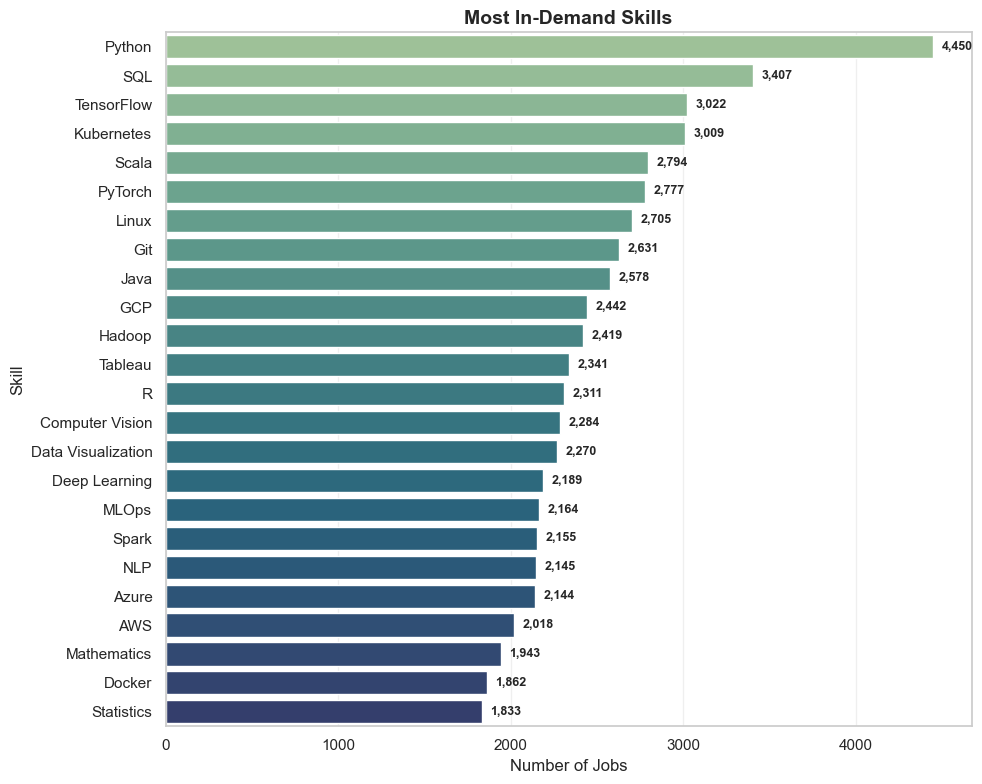

In [181]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=skills_df.head(30),
    x='Count',
    y='Skill',
    palette='crest'
)

plt.title('Most In-Demand Skills', fontsize=14, fontweight='bold')
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('Skill', fontsize=12)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(skills_df.head(30)['Count']):
    plt.text(v + 50, i, f'{v:,}', va='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

#### Years of Experience vs Salary

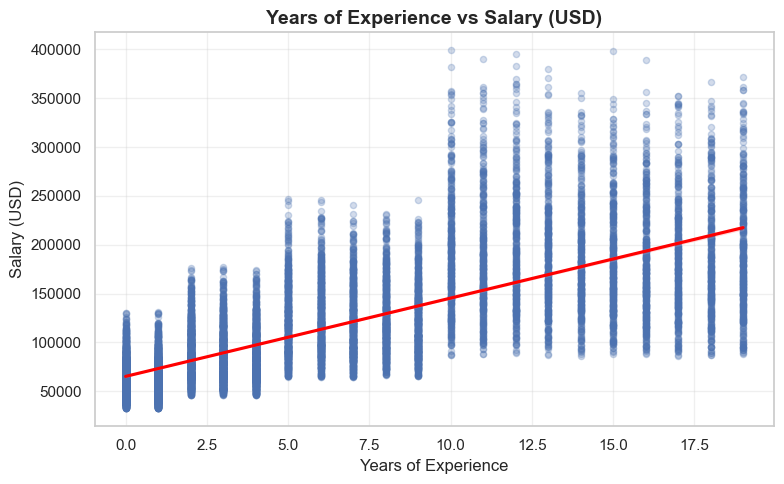

In [182]:
plt.figure(figsize=(8,5))
sns.regplot(data=data, x='years_experience', y='salary_usd',
            scatter_kws={'alpha':0.25, 's':20}, line_kws={'color':'red'})
plt.title('Years of Experience vs Salary (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience'); plt.ylabel('Salary (USD)')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### Correlation Matrix

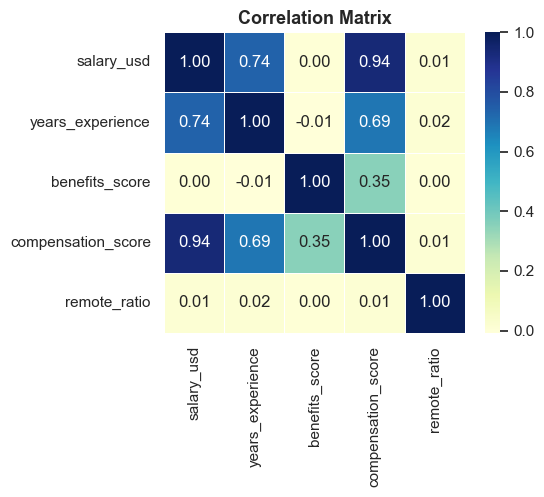

In [183]:
corr_cols = ['salary_usd', 'years_experience', 'benefits_score', 'compensation_score','remote_ratio']
corr_matrix = data[corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    linewidths=0.5, 
    square=True
)

plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Data Modeling

สร้าง Model เพื่อเรียนรู้ของการคาดการณ์ 'salary_usd' ซึ่งสามารถสร้างประโยชน์ได้ เช่น:
- ลูกจ้างประเมินรายได้ของตัวเองได้
- บริษัทสามารถวิเคราะห์ฐานเงินเดือนที่เหมาะสม
- เข้าใจปัจจัยที่มีอิทธิพลแก่งานเกี่ยวกัับ AI

**Target Variable:**
- `salary_usd`: เงินเดือนหน่วย USD

**Features we'll use:**
1. Numerical Features:
   - `remote_ratio`
   - `years_experience`
   - `job_description_length`
   - `benefits_score`
   - `days_to_apply`

2. Categorical Features:
   - `experience_level`
   - `employment_type`
   - `company_size`
   - `required_skills`
   - `education_required`
   - `industry`
   - `work_type`
   - `experience_category`
   - `benefits_category`

In [184]:
numerical_features = ['remote_ratio','years_experience',
                      'job_description_length','benefits_score',
                      'days_to_apply']
categorical_features =['experience_level','employment_type',
                      'company_size','required_skills',
                      'education_required','industry','work_type',
                      'experience_category','benefits_category']

X = data[numerical_features+categorical_features]
Y = data['salary_usd']

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25, random_state=42)
print("training set shape =",X_train.shape)
print("testing set shape =",X_test.shape)

training set shape = (11250, 14)
testing set shape = (3750, 14)


In [186]:
numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])

categorical_transformer=Pipeline(steps=[('onehot',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num',numerical_transformer,numerical_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test) 

print("Transformed training set shape = ",X_train_transformed.shape)
print("Transformed testing set shape = ",X_test_transformed.shape)

# Get feature names after preprocessing
feature_names_out = (
    numerical_features +
    [f"{feature}_{val}" for feature, vals in 
     zip(categorical_features, 
         preprocessor.named_transformers_['cat'].named_steps['onehot'].categories_)
     for val in vals[1:]]
)


Transformed training set shape =  (11250, 10491)
Transformed testing set shape =  (3750, 10491)


In [ ]:
#train model 
models = {'LinearRegression' : LinearRegression(),
          'Ridge regression' : Ridge(alpha=1.0),
          'Random Forest' : RandomForestRegressor(n_estimators=200,random_state=42),
          'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200,random_state=42)}
#train
results={}
for name,model in models.items():
    model.fit(X_train_transformed,Y_train)

    #prediction
    Y_pred = model.predict(X_test_transformed)

    #evaluate
    mse = mean_squared_error(Y_test,Y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test,Y_pred)
    r2 = r2_score(Y_test,Y_pred)

    #store results
    results[name]={
        'RMSE' : rmse,
        'MAE' : mae,
        'R2' : r2
     }

results_df = pd.DataFrame(results).T
print("Model Performance = ")
print("\n",results_df)

In [ ]:
# Visualize 
plt.figure(figsize=(12, 6))

# Plot RMSE
plt.subplot(1, 2, 1)
plt.bar(results_df.index, results_df['RMSE'], color='skyblue')
plt.title('Root Mean Square Error by Model')
plt.xticks(rotation=45)
plt.ylabel('RMSE ($)')

# Plot R2 Score
plt.subplot(1, 2, 2)
plt.bar(results_df.index, results_df['R2'], color='lightgreen')
plt.title('R² Score by Model')
plt.xticks(rotation=45)
plt.ylabel('R²')

plt.tight_layout()
plt.show()


best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]
print(f"\nBest performing model: {best_model_name}")
print(f"R² Score: {results_df.loc[best_model_name, 'R2']:.4f}")
print(f"RMSE: ${results_df.loc[best_model_name, 'RMSE']:,.2f}")
print(f"MAE: ${results_df.loc[best_model_name, 'MAE']:,.2f}")


In [ ]:
# Check feature importance for the best model
if hasattr(best_model, 'feature_importances_'):
    try:
        importances = best_model.feature_importances_
        
        if len(feature_names_out) != len(importances):
            print(f"Warning: Number of features ({len(importances)}) doesn't match number of feature names ({len(feature_names_out)})")
            # Create generic feature names if needed
            feature_names = [f'Feature_{i}' for i in range(len(importances))]
        else:
            feature_names = feature_names_out
        
        feature_importance = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        })
        
    
        feature_importance = feature_importance.sort_values('importance', ascending=False)
        

        plt.figure(figsize=(12, 6))
        plt.bar(range(15), feature_importance['importance'][:15])
        plt.xticks(range(15), feature_importance['feature'][:15], rotation=45, ha='right')
        plt.title(f'Top 15 Most Important Features for {best_model_name}')
        plt.xlabel('Features')
        plt.ylabel('Importance Score')
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 Most Important Features:")
        print(feature_importance.head(10))
    except Exception as e:
        print(f"Error analyzing feature importance: {str(e)}")
else:
    print(f"The {best_model_name} does not support feature importance analysis.")

#### Model Summary and Evaluation

เราได้สร้างและเปรียบเทียบ model ที่หลากหลายได้แก่
1. **Models Tested:**
   - Linear Regression
   - Ridge Regression
   - Random Forest
   - Gradient Boosting

2. **Evaluation :**
   - RMSE (Root Mean Square Error): วัดขนาดเฉลี่ยของข้อผิดพลาดในการคาดการณ์
   - MAE (Mean Absolute Error) :
   ความแตกต่างสัมบูรณ์โดยเฉลี่ยระหว่างเงินเดือนที่คาดการณ์ไว้กับเงินเดือนจริง
   - R² Score: สัดส่วนความแปรปรวนในตัวแปรเป้าหมายที่อธิบายโดยแบบจำลอง

3. **Best Performing Model:**
   ผลลัพธ์ทางเราได้วัดจาก:
   - ความแม่นยำในการทำนาย (lowest RMSE and MAE)
   - ความแปรปรวนที่อธิบายได้  (highest R² score)

4. **Feature Importance:**
   - แสดงให้เห็นว่า years_experience มีความสำคัญมากที่สุด
   - มีผลประโยชน์ทั้งผู้จ้างและผู้ว่าจ้าง

5. **Model Usage:**
   แบบจำลองนี้สามารถใช้เพื่อ:
   - ประเมินอัตราเงินเดือนตามตลาดสำหรับตำแหน่งงาน AI
   - ทำความเข้าใจผลกระทบของปัจจัยต่างๆ ที่มีต่อเงินเดือน
   - ช่วยในการเจรจาเงินเดือน
   - เป็นแนวทางในการตัดสินใจจ้างงาน